# Traffic Flow Model Evaluation and Research Comparison

This notebook evaluates the baseline **LSTM**, **GRU**, and **CNN** traffic-flow prediction models.

A separate research section compares the original **GRU** model with **GRU_MIXED_CONTROLLED**, which applies mixed precision training under the same controlled training configuration as the baseline GRU.

### Evaluation structure

1. **Baseline model comparison:** LSTM vs GRU vs CNN  
2. **Research comparison:** GRU vs GRU_MIXED_CONTROLLED  
3. **Research interpretation:** whether mixed precision maintained comparable predictive quality  


## 1. Load saved evaluation outputs

In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Find the project root whether this notebook is opened from the project root
# or from a subfolder such as models/.
current_folder = Path.cwd()
project_root = None

for folder in [current_folder, *current_folder.parents]:
    if (folder / "saved_models").exists():
        project_root = folder
        break

if project_root is None:
    raise FileNotFoundError(
        "Cannot find the saved_models folder. "
        "Place this notebook inside the project folder or one of its subfolders."
    )

saved_dir = project_root / "saved_models"
metrics_file = saved_dir / "model_metrics.csv"
history_file = saved_dir / "model_training_history.csv"
predictions_file = saved_dir / "model_test_predictions.csv"

required_files = [metrics_file, history_file, predictions_file]
missing_files = [str(path) for path in required_files if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing evaluation output files. Run all four training scripts first:\n"
        + "\n".join(missing_files)
    )

metrics_df = pd.read_csv(metrics_file)
history_df = pd.read_csv(history_file)
predictions_df = pd.read_csv(predictions_file)

predictions_df["target_timestamp"] = pd.to_datetime(
    predictions_df["target_timestamp"],
    errors="coerce",
)

if predictions_df["target_timestamp"].isna().any():
    raise ValueError("model_test_predictions.csv contains invalid timestamps.")

print("Loaded metrics:", metrics_file)
print("Loaded training history:", history_file)
print("Loaded test predictions:", predictions_file)

display(metrics_df)


Loaded metrics: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/saved_models/model_metrics.csv
Loaded training history: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/saved_models/model_training_history.csv
Loaded test predictions: /Users/truonghuuminhhai/Documents/COS30019/Assignment2B/cos30019_assignment2_b/saved_models/model_test_predictions.csv


,Model,MAE,RMSE,R2,WAPE_percent,MAPE_percent
0,LSTM,37.014435,51.119915,0.964699,10.288519,38.661070
1,GRU,43.571325,53.716906,0.961021,12.111071,67.979954
2,CNN,30.520636,44.621161,0.973104,8.483505,22.912052
3,GRU_MIXED_CONTROLLED,40.636928,51.118948,0.964700,11.295427,61.282854


## 2. Check saved outputs and separate baseline from research

In [42]:
BASELINE_MODELS = ["LSTM", "GRU", "CNN"]
RESEARCH_MODEL = "GRU_MIXED_CONTROLLED"
RESEARCH_MODELS = ["GRU", RESEARCH_MODEL]
ALL_EXPECTED_MODELS = BASELINE_MODELS + [RESEARCH_MODEL]

for output_name, output_df in [
    ("metrics", metrics_df),
    ("training history", history_df),
    ("test predictions", predictions_df),
]:
    available_models = set(output_df["Model"].astype(str))

    missing_baseline = [
        model_name for model_name in BASELINE_MODELS
        if model_name not in available_models
    ]

    if missing_baseline:
        print(f"Missing baseline {output_name} for:", missing_baseline)
    else:
        print(f"All baseline models are available in {output_name}.")

    if RESEARCH_MODEL in available_models:
        print(f"{RESEARCH_MODEL} is available in {output_name}.")
    else:
        print(f"Missing research {output_name} for: {RESEARCH_MODEL}")

missing_required = [
    model_name
    for model_name in ALL_EXPECTED_MODELS
    if model_name not in set(metrics_df["Model"].astype(str))
]

if missing_required:
    raise ValueError(
        "Run all baseline and research training scripts before evaluating. "
        f"Missing metrics for: {missing_required}"
    )

# Baseline architecture comparison only.
baseline_comparison_df = (
    metrics_df[metrics_df["Model"].isin(BASELINE_MODELS)]
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
)

print("\nBaseline Model Comparison")
display(baseline_comparison_df)

best_baseline_model = baseline_comparison_df.loc[0, "Model"]
best_baseline_rmse = baseline_comparison_df.loc[0, "RMSE"]

print(f"Best baseline model based on lowest RMSE: {best_baseline_model}")
print(f"Lowest baseline RMSE: {best_baseline_rmse:.4f}")

# Variables used by baseline visualisation cells.
comparison_df = baseline_comparison_df.copy()
model_order = BASELINE_MODELS.copy()


All baseline models are available in metrics.
GRU_MIXED_CONTROLLED is available in metrics.
All baseline models are available in training history.
GRU_MIXED_CONTROLLED is available in training history.
All baseline models are available in test predictions.
GRU_MIXED_CONTROLLED is available in test predictions.

Baseline Model Comparison


,Model,MAE,RMSE,R2,WAPE_percent,MAPE_percent
0,CNN,30.520636,44.621161,0.973104,8.483505,22.912052
1,LSTM,37.014435,51.119915,0.964699,10.288519,38.661070
2,GRU,43.571325,53.716906,0.961021,12.111071,67.979954


Best baseline model based on lowest RMSE: CNN
Lowest baseline RMSE: 44.6212


## 3. Baseline model metric comparison

This section compares the three required/selected baseline algorithms: **LSTM**, **GRU**, and **CNN**


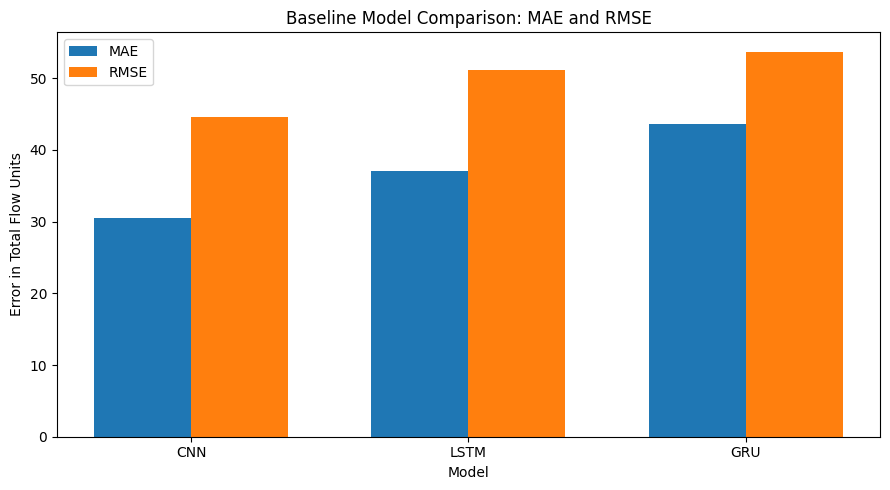

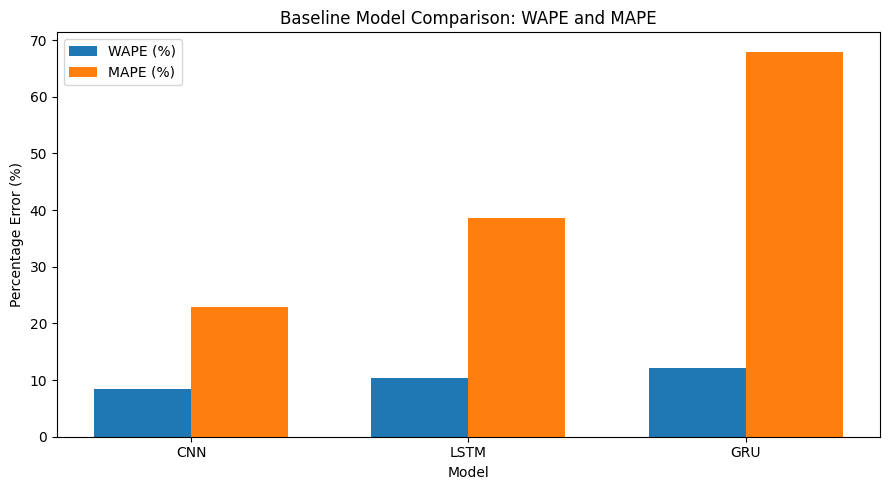

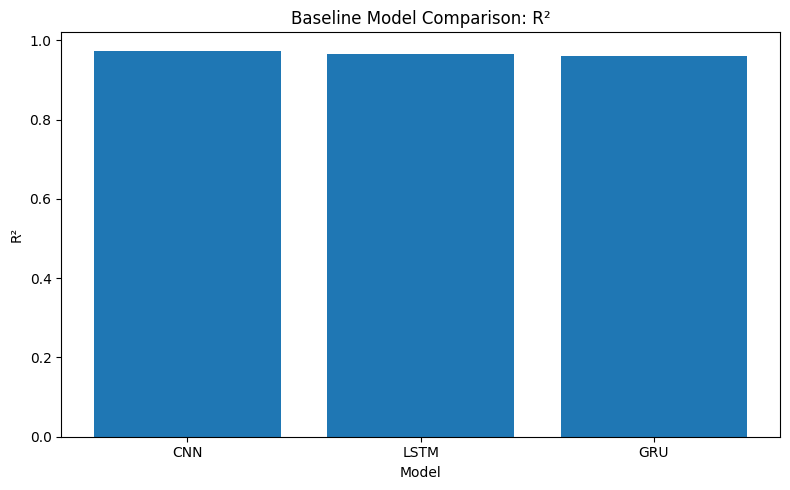

In [54]:
plt.figure(figsize=(9, 5))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width / 2, comparison_df["MAE"], width, label="MAE")
plt.bar(x + width / 2, comparison_df["RMSE"], width, label="RMSE")

plt.xticks(x, comparison_df["Model"])
plt.title("Baseline Model Comparison: MAE and RMSE")
plt.xlabel("Model")
plt.ylabel("Error in Total Flow Units")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))

plt.bar(x - width / 2, comparison_df["WAPE_percent"], width, label="WAPE (%)")
plt.bar(x + width / 2, comparison_df["MAPE_percent"], width, label="MAPE (%)")

plt.xticks(x, comparison_df["Model"])
plt.title("Baseline Model Comparison: WAPE and MAPE")
plt.xlabel("Model")
plt.ylabel("Percentage Error (%)")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Model"], comparison_df["R2"])

plt.title("Baseline Model Comparison: R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()


## 4. Baseline training and validation behaviour

The best epoch is selected by the lowest validation loss. This section shows whether each baseline model was still improving or whether validation detected an earlier best point.


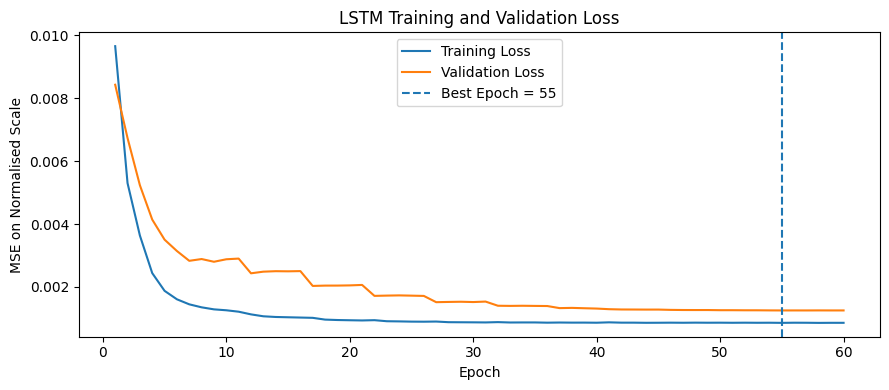

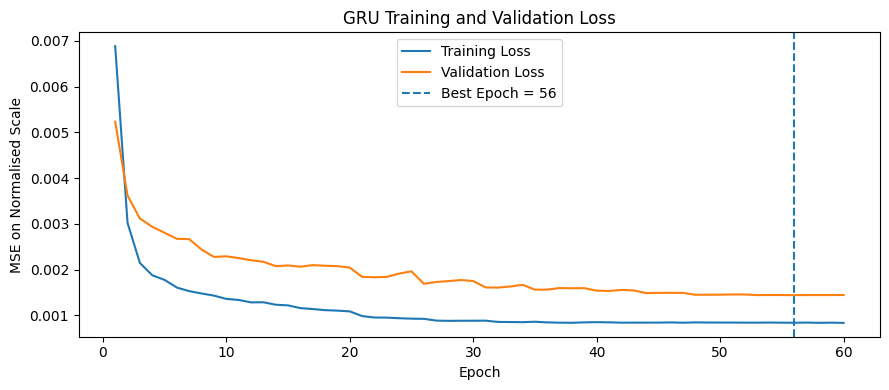

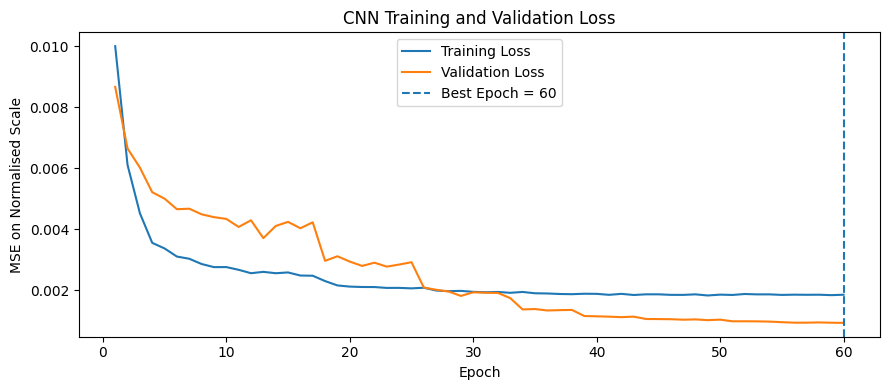

,Model,Epochs Run,Best Epoch by Validation Loss,Best Train Loss,Best Validation Loss,Validation Gap,Final Val Loss Increase,Interpretation
0,LSTM,60,55,0.000860,0.001255,0.000394,3.854511e-07,Best validation result before final epoch
1,GRU,60,56,0.000841,0.001443,0.000603,3.388617e-06,Best validation result before final epoch
2,CNN,60,60,0.001847,0.000923,-0.000924,0.000000e+00,Best validation result at final epoch


In [44]:
MAX_EPOCHS = 60
baseline_validation_rows = []

for model_name in model_order:
    model_history = (
        history_df[history_df["Model"] == model_name]
        .sort_values("Epoch")
        .copy()
    )

    if model_history.empty:
        raise ValueError(f"No training history found for {model_name}.")

    best_row = model_history.loc[model_history["val_loss"].idxmin()]
    final_row = model_history.iloc[-1]

    best_epoch = int(best_row["Epoch"])
    epochs_run = int(final_row["Epoch"])
    best_val_loss = float(best_row["val_loss"])
    final_increase = float(final_row["val_loss"] - best_row["val_loss"])

    if epochs_run < MAX_EPOCHS:
        convergence = "Stopped before maximum epochs"
    elif best_epoch == epochs_run:
        convergence = "Best validation result at final epoch"
    else:
        convergence = "Best validation result before final epoch"

    baseline_validation_rows.append(
        {
            "Model": model_name,
            "Epochs Run": epochs_run,
            "Best Epoch by Validation Loss": best_epoch,
            "Best Train Loss": float(best_row["loss"]),
            "Best Validation Loss": best_val_loss,
            "Validation Gap": float(best_row["val_loss"] - best_row["loss"]),
            "Final Val Loss Increase": final_increase,
            "Interpretation": convergence,
        }
    )

    plt.figure(figsize=(9, 4))
    plt.plot(model_history["Epoch"], model_history["loss"], label="Training Loss")
    plt.plot(model_history["Epoch"], model_history["val_loss"], label="Validation Loss")
    plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
    plt.title(f"{model_name} Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE on Normalised Scale")
    plt.legend()
    plt.tight_layout()
    plt.show()

baseline_validation_df = pd.DataFrame(baseline_validation_rows)
display(baseline_validation_df)


## 5. Baseline average predicted traffic flow over the testing period

The chart averages all SCATS sites and all test days by time-of-day interval. It is used to compare how closely each baseline model follows the actual daily traffic pattern.


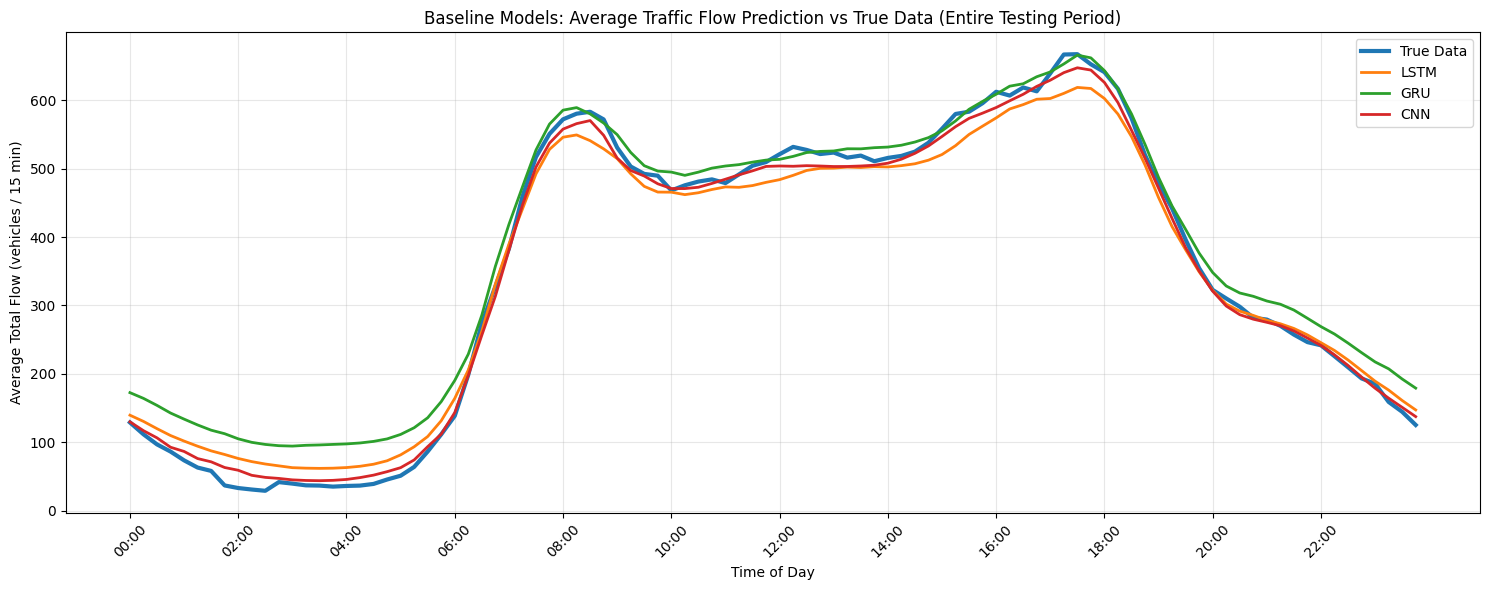

Evaluation data used: Testing set only
Testing period: 2006-10-26 00:00:00 to 2006-10-31 23:45:00
Number of SCATS sites included: 40
Number of testing days included: 6
Baseline models included: ['LSTM', 'GRU', 'CNN']


In [45]:
TEST_START = pd.Timestamp("2006-10-26 00:00:00")
TEST_END = pd.Timestamp("2006-10-31 23:45:00")

plot_df = predictions_df[
    (predictions_df["target_timestamp"] >= TEST_START)
    & (predictions_df["target_timestamp"] <= TEST_END)
    & (predictions_df["Model"].isin(model_order))
].copy()

if plot_df.empty:
    raise ValueError("No baseline testing predictions found in the selected testing period.")

plot_df["interval"] = (
    plot_df["target_timestamp"].dt.hour * 4
    + plot_df["target_timestamp"].dt.minute // 15
)

time_labels = [
    f"{hour:02d}:{minute:02d}"
    for hour in range(24)
    for minute in [0, 15, 30, 45]
]

actual_average = (
    plot_df[["site_id", "target_timestamp", "interval", "actual_total_flow"]]
    .drop_duplicates(["site_id", "target_timestamp"])
    .groupby("interval", as_index=False)["actual_total_flow"]
    .mean()
    .rename(columns={"actual_total_flow": "average_actual_flow"})
)

predicted_average = (
    plot_df
    .groupby(["Model", "interval"], as_index=False)["predicted_total_flow"]
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    actual_average["interval"],
    actual_average["average_actual_flow"],
    label="True Data",
    linewidth=3,
)

for model_name in model_order:
    model_average = (
        predicted_average[predicted_average["Model"] == model_name]
        .sort_values("interval")
    )

    plt.plot(
        model_average["interval"],
        model_average["predicted_total_flow"],
        label=model_name,
        linewidth=2,
    )

tick_positions = list(range(0, 96, 8))
tick_labels = [time_labels[position] for position in tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.title(
    "Baseline Models: Average Traffic Flow Prediction vs True Data "
    "(Entire Testing Period)"
)
plt.xlabel("Time of Day")
plt.ylabel("Average Total Flow (vehicles / 15 min)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Evaluation data used: Testing set only")
print("Testing period:", TEST_START, "to", TEST_END)
print("Number of SCATS sites included:", plot_df["site_id"].nunique())
print("Number of testing days included:", plot_df["target_timestamp"].dt.date.nunique())
print("Baseline models included:", model_order)


## 6. Baseline predicted vs actual scatter plots

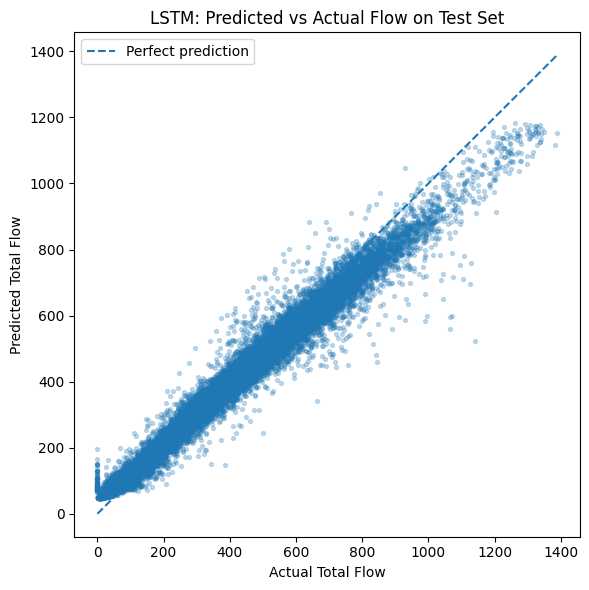

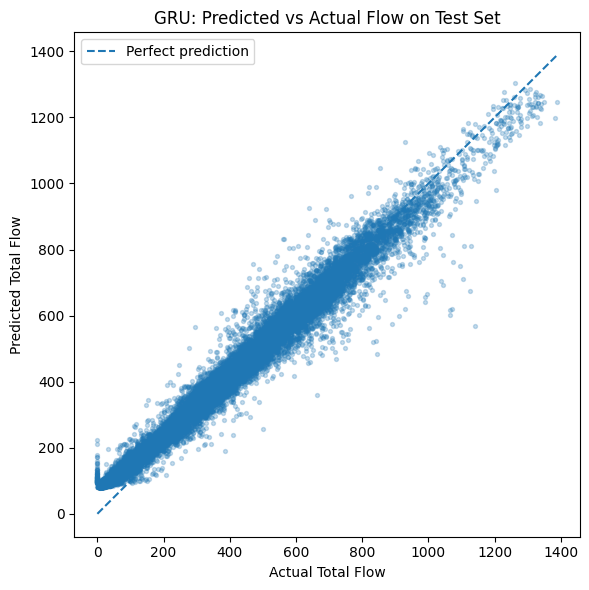

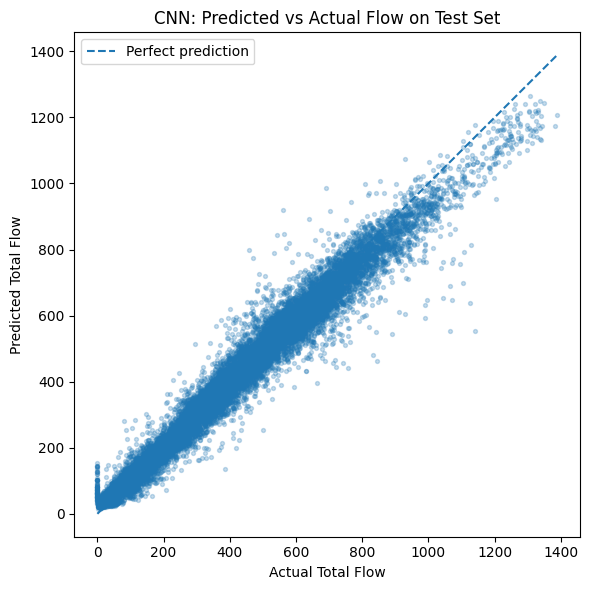

In [46]:
for model_name in model_order:
    model_predictions = predictions_df[
        predictions_df["Model"] == model_name
    ].copy()

    if model_predictions.empty:
        raise ValueError(f"No test predictions found for {model_name}.")

    actual_values = model_predictions["actual_total_flow"]
    predicted_values = model_predictions["predicted_total_flow"]

    minimum = min(actual_values.min(), predicted_values.min())
    maximum = max(actual_values.max(), predicted_values.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(actual_values, predicted_values, s=8, alpha=0.25)
    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        label="Perfect prediction",
    )
    plt.title(f"{model_name}: Predicted vs Actual Flow on Test Set")
    plt.xlabel("Actual Total Flow")
    plt.ylabel("Predicted Total Flow")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Baseline absolute prediction error distribution

A model with a lower median error and narrower error spread is generally more consistent on the test set.


/var/folders/pn/c_xh77l93q7g57d_3924ck5r0000gn/T/ipykernel_38539/2605596712.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(error_data, labels=model_order, showfliers=False)


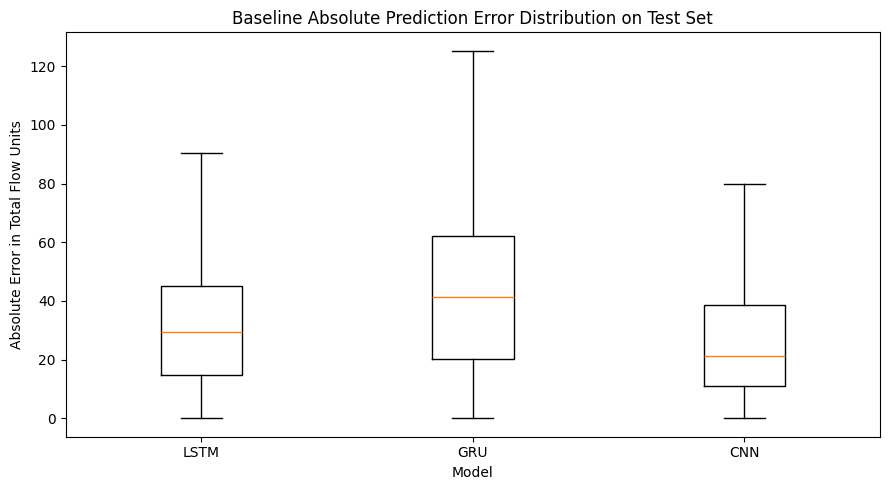

In [47]:
error_data = [
    predictions_df[
        predictions_df["Model"] == model_name
    ]["absolute_error"].dropna()
    for model_name in model_order
]

plt.figure(figsize=(9, 5))
plt.boxplot(error_data, labels=model_order, showfliers=False)
plt.title("Baseline Absolute Prediction Error Distribution on Test Set")
plt.xlabel("Model")
plt.ylabel("Absolute Error in Total Flow Units")
plt.tight_layout()
plt.show()


# Research Evaluation: Original GRU vs Mixed-Precision GRU

The purpose of this controlled comparison is to isolate the effect of mixed precision on predictive quality as far as possible. Any claim about training-speed or memory improvement also requires runtime or memory evidence


## 8. Research metrics comparison

In [48]:
research_metrics_df = (
    metrics_df[metrics_df["Model"].isin(RESEARCH_MODELS)]
    .set_index("Model")
    .reindex(RESEARCH_MODELS)
    .reset_index()
)

if research_metrics_df.isna().any().any():
    raise ValueError(
        "Missing GRU or GRU_MIXED_CONTROLLED metrics. "
        "Run train_gru.py and train_gru_research.py first."
    )

original_gru = research_metrics_df[
    research_metrics_df["Model"] == "GRU"
].iloc[0]

mixed_gru = research_metrics_df[
    research_metrics_df["Model"] == RESEARCH_MODEL
].iloc[0]

research_comparison_table = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2", "WAPE_percent", "MAPE_percent"],
        "Original GRU": [
            original_gru["MAE"],
            original_gru["RMSE"],
            original_gru["R2"],
            original_gru["WAPE_percent"],
            original_gru["MAPE_percent"],
        ],
        "Mixed-Precision GRU": [
            mixed_gru["MAE"],
            mixed_gru["RMSE"],
            mixed_gru["R2"],
            mixed_gru["WAPE_percent"],
            mixed_gru["MAPE_percent"],
        ],
    }
)

research_comparison_table["Difference (Mixed - Original)"] = (
    research_comparison_table["Mixed-Precision GRU"]
    - research_comparison_table["Original GRU"]
)

display(research_comparison_table)

print("Research Interpretation")
print("-" * 70)
print("MAE, RMSE, WAPE and MAPE: lower values are better.")
print("R²: higher values are better.")
print()

if mixed_gru["RMSE"] < original_gru["RMSE"]:
    print(
        "The mixed-precision GRU achieved a lower RMSE than the original GRU "
        f"({mixed_gru['RMSE']:.4f} vs {original_gru['RMSE']:.4f})."
    )
    print(
        "Under the selected RMSE criterion, the controlled mixed-precision "
        "implementation achieved a better observed predictive result."
    )
else:
    print(
        "The original GRU achieved a lower RMSE than the mixed-precision GRU "
        f"({original_gru['RMSE']:.4f} vs {mixed_gru['RMSE']:.4f})."
    )
    print(
        "In this controlled run, mixed precision did not improve predictive "
        "accuracy based on RMSE."
    )

print(
    "This section evaluates predictive quality only. Training-efficiency "
    "claims require stored timing or memory measurements for both GRU versions."
)


,Metric,Original GRU,Mixed-Precision GRU,Difference (Mixed - Original)
0,MAE,43.571325,40.636928,-2.934397
1,RMSE,53.716906,51.118948,-2.597958
2,R2,0.961021,0.964700,0.003679
3,WAPE_percent,12.111071,11.295427,-0.815644
4,MAPE_percent,67.979954,61.282854,-6.697100


Research Interpretation
----------------------------------------------------------------------
MAE, RMSE, WAPE and MAPE: lower values are better.
R²: higher values are better.

The mixed-precision GRU achieved a lower RMSE than the original GRU (51.1189 vs 53.7169).
Under the selected RMSE criterion, the controlled mixed-precision implementation achieved a better observed predictive result.
This section evaluates predictive quality only. Training-efficiency claims require stored timing or memory measurements for both GRU versions.


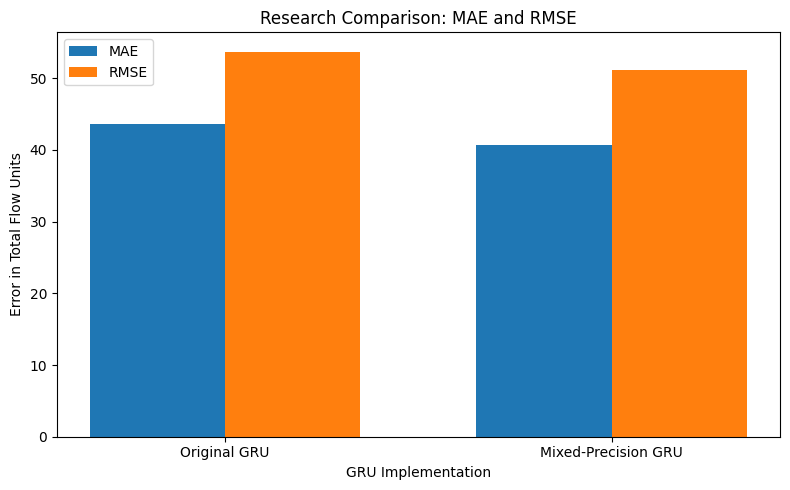

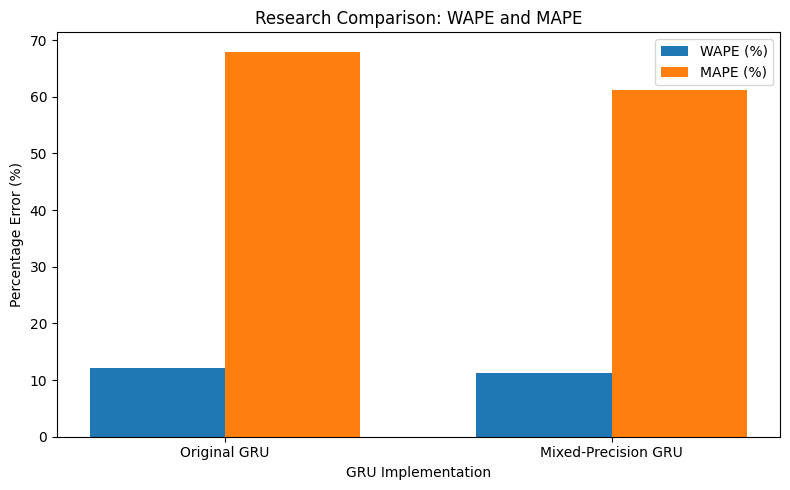

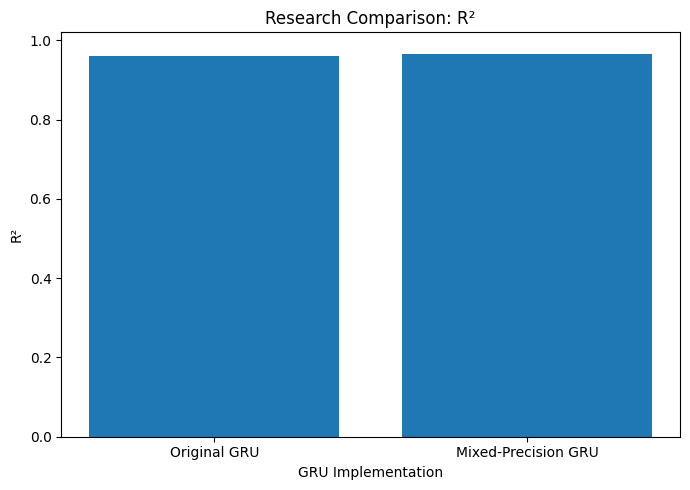

In [49]:
plt.figure(figsize=(8, 5))

x = np.arange(len(research_metrics_df))
width = 0.35
labels = ["Original GRU", "Mixed-Precision GRU"]

plt.bar(x - width / 2, research_metrics_df["MAE"], width, label="MAE")
plt.bar(x + width / 2, research_metrics_df["RMSE"], width, label="RMSE")
plt.xticks(x, labels)
plt.title("Research Comparison: MAE and RMSE")
plt.xlabel("GRU Implementation")
plt.ylabel("Error in Total Flow Units")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.bar(x - width / 2, research_metrics_df["WAPE_percent"], width, label="WAPE (%)")
plt.bar(x + width / 2, research_metrics_df["MAPE_percent"], width, label="MAPE (%)")
plt.xticks(x, labels)
plt.title("Research Comparison: WAPE and MAPE")
plt.xlabel("GRU Implementation")
plt.ylabel("Percentage Error (%)")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

plt.bar(labels, research_metrics_df["R2"])
plt.title("Research Comparison: R²")
plt.xlabel("GRU Implementation")
plt.ylabel("R²")
plt.ylim(0, 1.02)
plt.tight_layout()
plt.show()


## 9. Research validation and convergence comparison

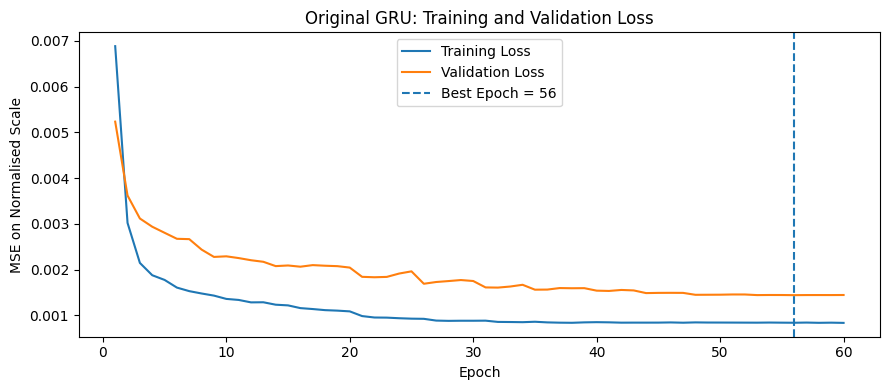

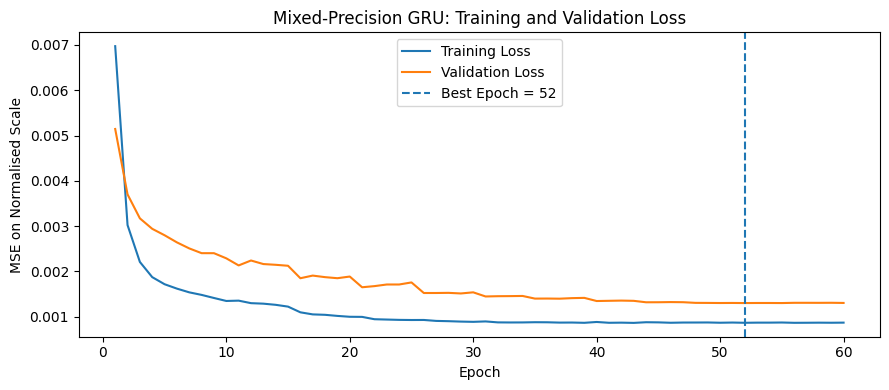

,Implementation,Epochs Run,Best Epoch by Validation Loss,Best Train Loss,Best Validation Loss,Validation Gap,Final Val Loss Increase
0,Original GRU,60,56,0.000841,0.001443,0.000603,0.000003
1,Mixed-Precision GRU,60,52,0.000866,0.001302,0.000436,0.000003


Implementation with the lower best validation loss: Mixed-Precision GRU


In [50]:
research_validation_rows = []

for model_name, display_name in [
    ("GRU", "Original GRU"),
    (RESEARCH_MODEL, "Mixed-Precision GRU"),
]:
    model_history = (
        history_df[history_df["Model"] == model_name]
        .sort_values("Epoch")
        .copy()
    )

    if model_history.empty:
        raise ValueError(f"No training history found for {model_name}.")

    best_row = model_history.loc[model_history["val_loss"].idxmin()]
    final_row = model_history.iloc[-1]

    best_epoch = int(best_row["Epoch"])
    epochs_run = int(final_row["Epoch"])

    research_validation_rows.append(
        {
            "Implementation": display_name,
            "Epochs Run": epochs_run,
            "Best Epoch by Validation Loss": best_epoch,
            "Best Train Loss": float(best_row["loss"]),
            "Best Validation Loss": float(best_row["val_loss"]),
            "Validation Gap": float(best_row["val_loss"] - best_row["loss"]),
            "Final Val Loss Increase": float(
                final_row["val_loss"] - best_row["val_loss"]
            ),
        }
    )

    plt.figure(figsize=(9, 4))
    plt.plot(model_history["Epoch"], model_history["loss"], label="Training Loss")
    plt.plot(model_history["Epoch"], model_history["val_loss"], label="Validation Loss")
    plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
    plt.title(f"{display_name}: Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE on Normalised Scale")
    plt.legend()
    plt.tight_layout()
    plt.show()

research_validation_df = pd.DataFrame(research_validation_rows)
display(research_validation_df)

best_validation_implementation = (
    research_validation_df
    .sort_values("Best Validation Loss")
    .iloc[0]["Implementation"]
)

print(
    "Implementation with the lower best validation loss:",
    best_validation_implementation,
)


## 10. Research average traffic-flow prediction comparison

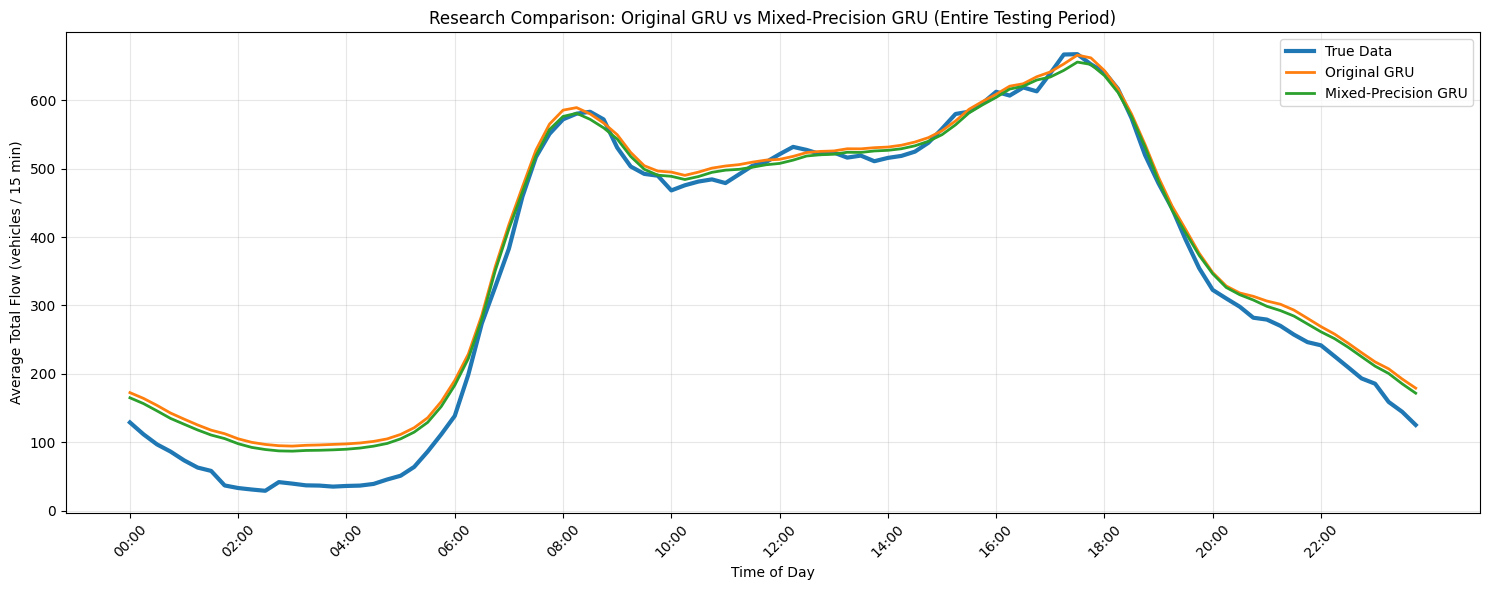

In [51]:
research_plot_df = predictions_df[
    (predictions_df["Model"].isin(RESEARCH_MODELS))
    & (predictions_df["target_timestamp"] >= TEST_START)
    & (predictions_df["target_timestamp"] <= TEST_END)
].copy()

if research_plot_df.empty:
    raise ValueError(
        "No GRU research predictions found in the testing period."
    )

research_plot_df["interval"] = (
    research_plot_df["target_timestamp"].dt.hour * 4
    + research_plot_df["target_timestamp"].dt.minute // 15
)

research_actual_average = (
    research_plot_df[
        ["site_id", "target_timestamp", "interval", "actual_total_flow"]
    ]
    .drop_duplicates(["site_id", "target_timestamp"])
    .groupby("interval", as_index=False)["actual_total_flow"]
    .mean()
    .rename(columns={"actual_total_flow": "average_actual_flow"})
)

research_predicted_average = (
    research_plot_df
    .groupby(["Model", "interval"], as_index=False)["predicted_total_flow"]
    .mean()
)

plt.figure(figsize=(15, 6))

plt.plot(
    research_actual_average["interval"],
    research_actual_average["average_actual_flow"],
    label="True Data",
    linewidth=3,
)

for model_name, display_name in [
    ("GRU", "Original GRU"),
    (RESEARCH_MODEL, "Mixed-Precision GRU"),
]:
    model_average = (
        research_predicted_average[
            research_predicted_average["Model"] == model_name
        ]
        .sort_values("interval")
    )

    plt.plot(
        model_average["interval"],
        model_average["predicted_total_flow"],
        label=display_name,
        linewidth=2,
    )

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.title(
    "Research Comparison: Original GRU vs Mixed-Precision GRU "
    "(Entire Testing Period)"
)
plt.xlabel("Time of Day")
plt.ylabel("Average Total Flow (vehicles / 15 min)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 11. Research predicted vs actual scatter plots and error distribution

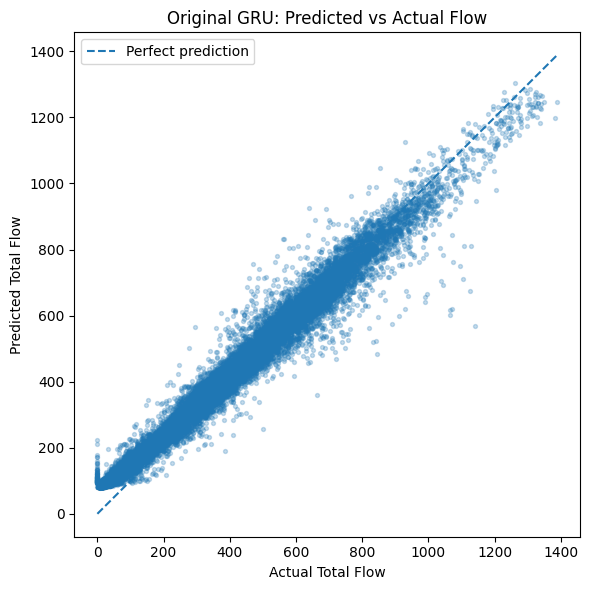

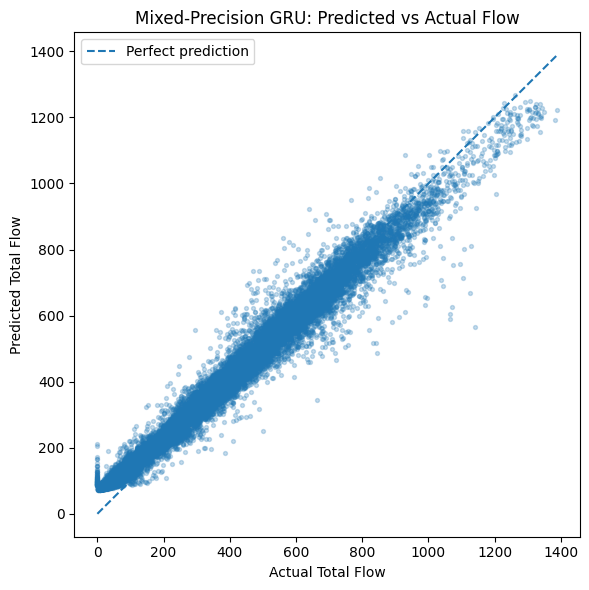

/var/folders/pn/c_xh77l93q7g57d_3924ck5r0000gn/T/ipykernel_38539/2565665100.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


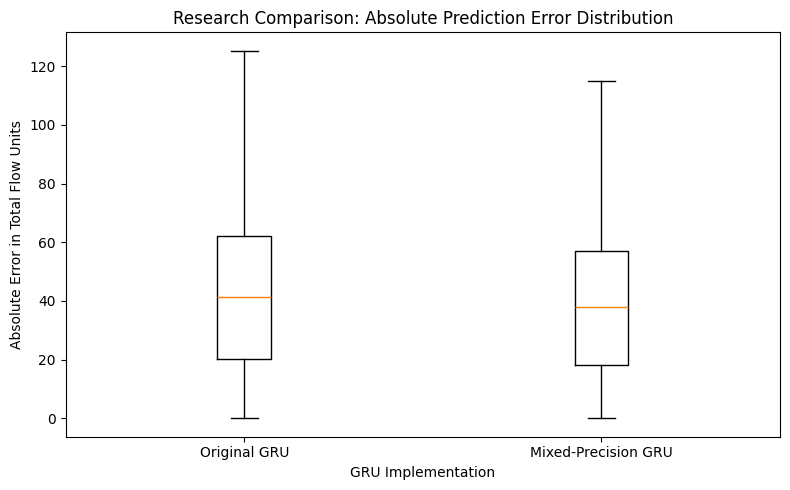

In [52]:
for model_name, display_name in [
    ("GRU", "Original GRU"),
    (RESEARCH_MODEL, "Mixed-Precision GRU"),
]:
    model_predictions = predictions_df[
        predictions_df["Model"] == model_name
    ].copy()

    if model_predictions.empty:
        raise ValueError(f"No test predictions found for {model_name}.")

    actual_values = model_predictions["actual_total_flow"]
    predicted_values = model_predictions["predicted_total_flow"]

    minimum = min(actual_values.min(), predicted_values.min())
    maximum = max(actual_values.max(), predicted_values.max())

    plt.figure(figsize=(6, 6))
    plt.scatter(actual_values, predicted_values, s=8, alpha=0.25)
    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        label="Perfect prediction",
    )
    plt.title(f"{display_name}: Predicted vs Actual Flow")
    plt.xlabel("Actual Total Flow")
    plt.ylabel("Predicted Total Flow")
    plt.legend()
    plt.tight_layout()
    plt.show()


research_error_data = [
    predictions_df[
        predictions_df["Model"] == model_name
    ]["absolute_error"].dropna()
    for model_name in RESEARCH_MODELS
]

plt.figure(figsize=(8, 5))
plt.boxplot(
    research_error_data,
    labels=["Original GRU", "Mixed-Precision GRU"],
    showfliers=False,
)
plt.title("Research Comparison: Absolute Prediction Error Distribution")
plt.xlabel("GRU Implementation")
plt.ylabel("Absolute Error in Total Flow Units")
plt.tight_layout()
plt.show()
